#🛠️ Preparación de los Datos

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

## Extracción del Archivo Tratado

In [2]:
# cargar dataset
datos = pd.read_csv('https://raw.githubusercontent.com/cotialbornoz/ChallengeTelecomX2/refs/heads/main/datos_tratados.csv')
# opciones de visualización: ver todas las columnas
pd.set_option('display.max_columns', None)
# ver dataset
datos.head(2)

,CustomerID,Churn,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,ChargesDaily,ChargesMonthly,ChargesTotal
0,0002-ORFBO,No,Female,No,Yes,Yes,9,Yes,No,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,2.19,65.6,593.3
1,0003-MKNFE,No,Male,No,No,No,9,Yes,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,No,Mailed check,2.00,59.9,542.4


In [3]:
# explorar dataset
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   CustomerID        7043 non-null   object 
 1   Churn             7043 non-null   object 
 2   Gender            7043 non-null   object 
 3   SeniorCitizen     7043 non-null   object 
 4   Partner           7043 non-null   object 
 5   Dependents        7043 non-null   object 
 6   Tenure            7043 non-null   int64  
 7   PhoneService      7043 non-null   object 
 8   MultipleLines     7043 non-null   object 
 9   InternetService   7043 non-null   object 
 10  OnlineSecurity    7043 non-null   object 
 11  OnlineBackup      7043 non-null   object 
 12  DeviceProtection  7043 non-null   object 
 13  TechSupport       7043 non-null   object 
 14  StreamingTV       7043 non-null   object 
 15  StreamingMovies   7043 non-null   object 
 16  Contract          7043 non-null   object 


In [4]:
# unificar datos
unificar_col = ['OnlineSecurity', 'OnlineBackup','DeviceProtection',
               'TechSupport','StreamingTV','StreamingMovies','MultipleLines', 'InternetService']

for col in unificar_col:
  datos[col] = datos[col].replace({'No internet service':'No'})
  datos[col] = datos[col].replace({'No phone service':'No'})
  datos[col] = datos[col].replace({'DSL':'Yes'})
  datos[col] = datos[col].replace({'Fiber optic':'Yes'})

## Eliminación de Columnas Irrelevantes

In [5]:
# eliminar columna CustomerID. no aporta valor al análisis ni a los modelos predictivos
datos = datos.drop(columns=['CustomerID'], axis=1)
datos.sample(2)

,Churn,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,ChargesDaily,ChargesMonthly,ChargesTotal
5626,Yes,Female,No,No,No,30,Yes,No,Yes,No,No,No,Yes,Yes,No,Month-to-month,No,Electronic check,2.84,85.15,2555.9
4649,No,Male,No,No,No,26,Yes,No,Yes,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,3.29,98.65,2537.0


In [6]:
# verificar si existen datos nulos
print(datos.isnull().sum())

Churn               0
Gender              0
SeniorCitizen       0
Partner             0
Dependents          0
Tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
ChargesDaily        0
ChargesMonthly      0
ChargesTotal        0
dtype: int64


### Variables numéricas

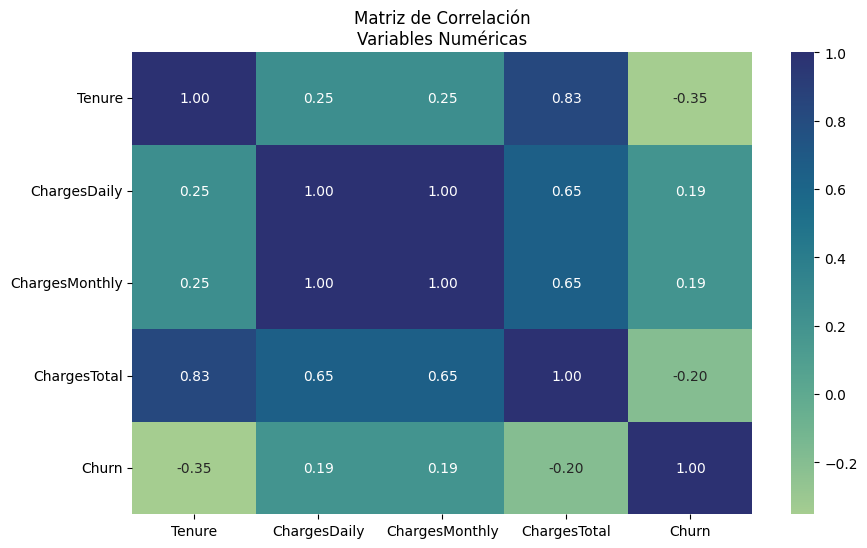

In [7]:
# seleccionar aquellas columnas cuyos datos sean numéricos
col_numericas = datos.select_dtypes(include=['int64', 'float64'])

# transformar datos de la columna Churn
col_numericas['Churn'] = datos['Churn'].map({'Yes': 1, 'No': 0})

# aplicar matriz de correlación
corr_numericos = col_numericas.corr()

# graficar
plt.figure(figsize=(10,6))
sns.heatmap(corr_numericos, annot=True, cmap='crest', fmt='.2f')
plt.title('Matriz de Correlación\nVariables Numéricas')
plt.show()

In [8]:
# eliminar columnas ChargesDaily y ChargesTotal
datos = datos.drop(columns=['ChargesDaily', 'ChargesTotal'])

### Variables categóricas

In [9]:
# seleccionar aquellas columnas cuyos datos sean object
col_categoricas = datos.select_dtypes(include=['object']).columns
col_categoricas = col_categoricas.drop('Churn')

# importar
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import chi2

# crear copia de dataset
datos_rankeados = datos.copy()

# convertir Churn para binario
datos_rankeados["Churn"] = datos_rankeados["Churn"].map({"Yes": 1, "No": 0})

# seleccionar variables categóricas para aplicar LabelEncoder
col_categoricas = datos_rankeados.select_dtypes(include=['object']).columns

le = LabelEncoder()
for col in col_categoricas:
  datos_rankeados[col] = le.fit_transform(datos_rankeados[col])

# separar X (variables independientes) y y (variable dependiente)
X = datos_rankeados[col_categoricas]
y = datos_rankeados['Churn']

# aplicar chi2
chi_puntajes, p_valores = chi2(X, y)

# crear dataframe para albergar los datos
chi_df = pd.DataFrame({
    "Variable" : X.columns, # Fixed: use X.columns to match lengths
    'Puntaje Chi2' : chi_puntajes,
    'Valor P' : p_valores
})

chi_df = chi_df.sort_values(by='Puntaje Chi2', ascending=False)
chi_df = chi_df.reset_index(drop=True)

# imprir
print(chi_df)

            Variable  Puntaje Chi2        Valor P
0           Contract   1115.780167  1.227941e-244
1     OnlineSecurity    147.295858   6.761696e-34
2        TechSupport    135.559783   2.490549e-31
3      SeniorCitizen    134.351545   4.576959e-31
4         Dependents    133.036443   8.876729e-31
5   PaperlessBilling    105.680863   8.661987e-25
6            Partner     82.412083   1.104764e-19
7    InternetService     79.251371   5.468939e-19
8      PaymentMethod     58.492250   2.040933e-14
9       OnlineBackup     31.217694   2.306541e-08
10  DeviceProtection     20.226662   6.878750e-06
11       StreamingTV     17.334235   3.134881e-05
12   StreamingMovies     16.242531   5.572887e-05
13     MultipleLines      6.548512   1.049719e-02
14            Gender      0.258699   6.110156e-01
15      PhoneService      0.097261   7.551421e-01


In [10]:
# buscar valor p-value de gender y phoneservice
p_value_gender = (6.110156 * (10**-1))
p_value_phoneservice = (7.551421 * (10**-1))
print(f'P-value de Gender: {p_value_gender}\nP-value de Phone Service: {p_value_phoneservice}')

P-value de Gender: 0.6110156
P-value de Phone Service: 0.7551421


In [11]:
# eliminar columnas Gender y PhoneService
datos = datos.drop(columns=['Gender', 'PhoneService'])

## Encoding

In [12]:
# variables explicativas
X = datos.drop(columns='Churn', axis=1)

# variable de respuesta
y = datos['Churn']

In [13]:
# importar
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OneHotEncoder

# seleccionar columnas
columnas = X.columns

# aplicar encoding
encoding = make_column_transformer((OneHotEncoder(drop='if_binary'),
                                    ['SeniorCitizen', 'Partner', 'Dependents', 'MultipleLines',
                                    'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                                    'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
                                    'PaperlessBilling', 'PaymentMethod']),
                                   remainder='passthrough',
                                   sparse_threshold=0,
                                   force_int_remainder_cols=False)

# calcular parámetros y transformar el conjunto de datos
X = encoding.fit_transform(X)

# crear nuevo dataframe
X = pd.DataFrame(X, columns=encoding.get_feature_names_out(columnas))

In [14]:
# renombrar nombres de columnas
X = X.rename(columns={
                      'onehotencoder__SeniorCitizen_Yes': 'SeniorCitizen',
                      'onehotencoder__Partner_Yes': 'Partner',
                      'onehotencoder__Dependents_Yes': 'Dependents',
                      'onehotencoder__MultipleLines_Yes': 'MultipleLines',
                      'onehotencoder__InternetService_Yes': 'InternetService',
                      'onehotencoder__OnlineSecurity_Yes': 'OnlineSecurity',
                      'onehotencoder__OnlineBackup_Yes': 'OnlineBackup',
                      'onehotencoder__DeviceProtection_Yes': 'DeviceProtection',
                      'onehotencoder__TechSupport_Yes': 'TechSupport',
                      'onehotencoder__StreamingTV_Yes': 'StreamingTV',
                      'onehotencoder__StreamingMovies_Yes': 'StramingMovies',
                      'onehotencoder__Contract_Month-to-month': 'Contract Month-to-month',
                      'onehotencoder__Contract_One year': 'Contract One year',
                      'onehotencoder__Contract_Two year': 'Contract Two year',
                      'onehotencoder__PaperlessBilling_Yes': 'PaperlessBilling',
                      'onehotencoder__PaymentMethod_Bank transfer (automatic)': 'PaymentMethod Bank transfer (automatic)',
                      'onehotencoder__PaymentMethod_Credit card (automatic)': 'PaymentMethod Credit card (automatic)',
                      'onehotencoder__PaymentMethod_Electronic check': 'PaymentMethod Electronic check',
                      'onehotencoder__PaymentMethod_Mailed check': 'PaymentMethod Mailed check',
                      'remainder__Tenure': 'Tenure',
                      'remainder__ChargesMonthly': 'ChargesMonthly'
})

In [15]:
X.sample(2)

,SeniorCitizen,Partner,Dependents,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StramingMovies,Contract Month-to-month,Contract One year,Contract Two year,PaperlessBilling,PaymentMethod Bank transfer (automatic),PaymentMethod Credit card (automatic),PaymentMethod Electronic check,PaymentMethod Mailed check,Tenure,ChargesMonthly
2393,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,71.0
6506,0.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,65.0,82.5


In [16]:
# aplicar labelencoder
y = le.fit_transform(y)

In [17]:
y

array([0, 0, 1, ..., 0, 0, 0])

## Verificación de la Proporción de Cancelación (Churn)

In [18]:
# crear series desde array
variable_churn = pd.Series(y).value_counts()

# almacenar en variables las cantidades y porcentajes
total = variable_churn.sum()
activos = variable_churn[0]
activos_p = round((activos/total) * 100, 2)
inactivos = variable_churn[1]
inactivos_p = round((inactivos/total) * 100, 2)

# crear un dataframe que almacena los datos
churn_df = pd.DataFrame({
    'Churn': ['No', 'Si'],
    'Cantidad': [activos, inactivos],
    'Porcentaje' : [activos_p, inactivos_p]
    })

print(churn_df)

  Churn  Cantidad  Porcentaje
0    No      5174       73.46
1    Si      1869       26.54


#🎯 Correlación y Selección de Variables

## Análisis de Correlación

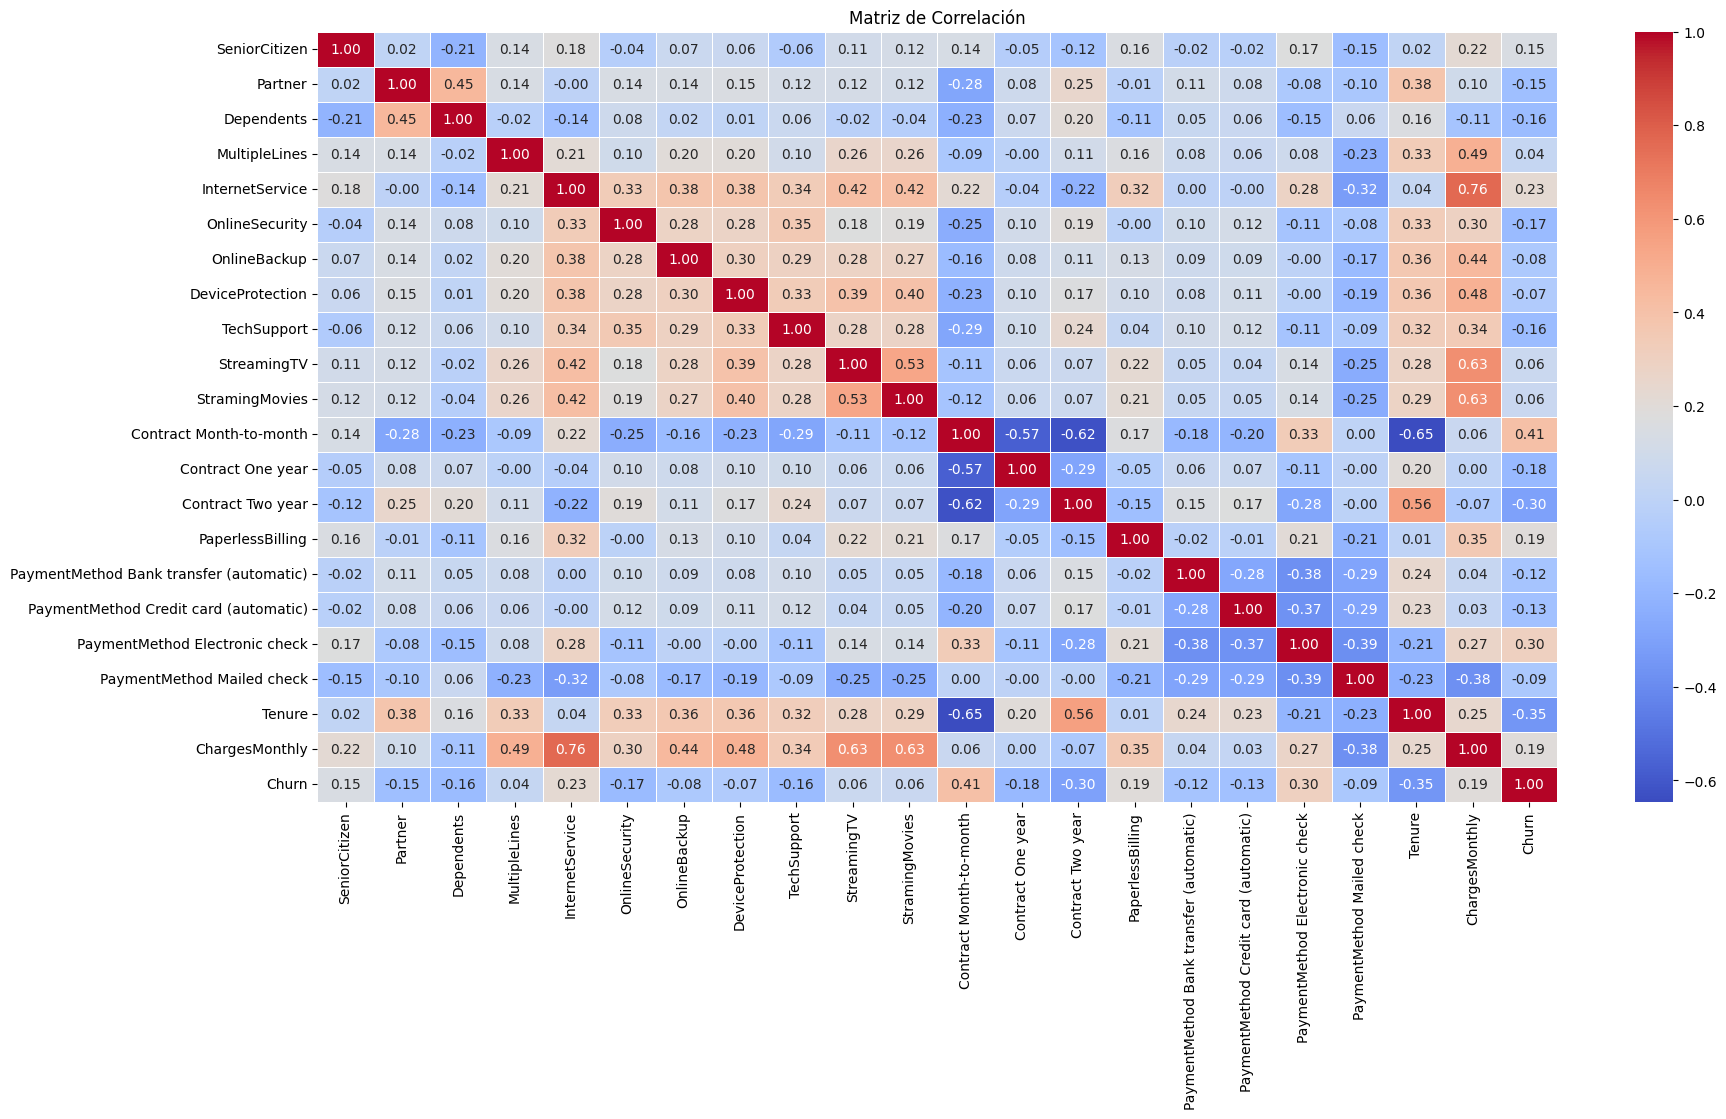

In [19]:
# crear un df con copias de nuestros datos ya separados
copia_x = X.copy()
copia_y = y.copy()

corr_df = copia_x
corr_df['Churn'] = copia_y

# aplicar matriz de correlación
corr_total = corr_df.corr()

# graficar
plt.figure(figsize=(20,10))
sns.heatmap(corr_total,
            annot=True,
            cmap='coolwarm',
            linewidth=.5,
            fmt=".2f")
plt.title('Matriz de Correlación')
plt.show()

## Análisis Dirigido

In [20]:
corr_df["Churn"] = corr_df["Churn"].map({0: "Activo", 1: "Canceló"})

In [21]:
# caracteristicas del cliente
fig = px.bar(corr_df,
             x='Churn',
             y=['SeniorCitizen', 'Partner', 'Dependents'],
             title="Fuga de clientes x Características del cliente")

fig.update_layout(
    xaxis_title='Fuga de clientes',
    yaxis_title='Características del cliente',
    template="gridon",
    legend_title_text='Características'
)

fig.show()

In [22]:
# tipo de contrato
fig = px.bar(corr_df,
             x='Churn',
             y=['Contract Month-to-month', 'Contract One year', 'Contract Two year'],
             title="Fuga de clientes x Tipo de contrato")

fig.update_layout(
    xaxis_title='Fuga de clientes',
    yaxis_title='Contrato',
    template="gridon",
    legend_title_text='Tipo de contrato'
)

fig.show()

In [23]:
# método de pago
fig = px.bar(corr_df,
             x='Churn',
             y=['PaymentMethod Bank transfer (automatic)',
                'PaymentMethod Credit card (automatic)',
                'PaymentMethod Electronic check',
                'PaymentMethod Mailed check'],
             title="Fuga de clientes x Método de Pago")

fig.update_layout(
    xaxis_title='Fuga de clientes',
    yaxis_title='Método de pago',
    template="gridon",
    legend_title_text='Método de pago'
)

fig.show()

In [24]:
# tenure
fig = px.box(
    corr_df,
    y='Churn',
    x='Tenure',
    color='Churn',
    labels={'Churn': 'Estado del Cliente'}
)

fig.update_layout(
    xaxis_title='Fuga de clientes',
    yaxis_title='Tenure',
    template='gridon'
)

fig.show()

In [25]:
# cargos mensuales
fig = px.box(
    corr_df,
    y="Churn",
    x="ChargesMonthly",
    color="Churn",
    labels={"Churn": "Estado del Cliente"}
)

fig.update_layout(
    xaxis_title="Fuga de clientes",
    yaxis_title="Cargos mensuales",
    template="gridon"
)

fig.show()

#🤖 Modelado Predictivo

## Separación de Datos

In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y,
                                        test_size=0.15,
                                        stratify=y,
                                        random_state=5)

## Creación de Modelos

### Modelo Dummy

In [27]:
# importar nuestro modelo dummy
from sklearn.dummy import DummyClassifier

# instanciar nuestro modelo
modelo_baseline = DummyClassifier()

# entrenar nuestros datos
modelo_baseline.fit(X_train,y_train)

# utilizar el método predict
y_pred_dummy = modelo_baseline.predict(X_test)

# puntuar
puntaje_dummy = modelo_baseline.score(X_test, y_test)

# imprimir
print(puntaje_dummy)

0.7350993377483444


### Árbol de Decisión

In [28]:
# importar nuestro modelo arbol
from sklearn.tree import DecisionTreeClassifier

# instanciar nuestro modelo
modelo_arbol = DecisionTreeClassifier(random_state=5)

# entrenar nuestros datos
modelo_arbol.fit(X_train,y_train)

# utilizar el método predict
y_test_pred_arbol = modelo_arbol.predict(X_test)
y_train_pred_arbol = modelo_arbol.predict(X_train)

# puntuar
puntaje_arbol = modelo_arbol.score(X_test, y_test)

# imprimir
print(puntaje_arbol)

0.7199621570482497


In [29]:
# buscar el max_depth para refinar nuestro modelo árbol de decision

# importar
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import KFold

# separar subconjuntos k
cv = KFold(n_splits=5, shuffle=True, random_state=5)

# establecer rango
param_grid = {'max_depth': list(range(1,10))}

# aplicar gridsearcgcv
grid = GridSearchCV (modelo_arbol,
                     scoring ='accuracy',
                     param_grid = param_grid,
                     cv = cv)

# entrenar
grid.fit(X_train, y_train)

# imprimir nuestro mejor parámetro
print(grid.best_estimator_)

DecisionTreeClassifier(max_depth=6, random_state=5)


In [30]:
# nuevo modelo arbol con max_depth agregado

# instanciar nuestro modelo
modelo_arbol = DecisionTreeClassifier(max_depth=6,
                                      random_state=5)

# entrenar nuestros datos
modelo_arbol.fit(X_train,y_train)

# utilizar el método predict
y_test_pred_arbol_md = modelo_arbol.predict(X_test)
y_train_pred_arbol_md = modelo_arbol.predict(X_train)

# puntuar
puntaje_arbol_md = modelo_arbol.score(X_test, y_test)

# imprimir
print(puntaje_arbol_md)

0.7965941343424787


### KNN

In [31]:
# importar nuestro modelo knn
from sklearn.neighbors import KNeighborsClassifier

# instanciar nuestro modelo
modelo_knn = KNeighborsClassifier()

# entrenar nuestros datos
modelo_knn.fit(X_train,y_train)

# utilizar el método predict
y_test_pred_knn = modelo_knn.predict(X_test)
y_train_pred_knn = modelo_knn.predict(X_train)

# puntuar
puntaje_knn = modelo_knn.score(X_test, y_test)

# imprimir
print(puntaje_knn)

0.7729422894985809


In [32]:
# el modelo KNN requiere normalización en los datos

# importar
from sklearn.preprocessing import MinMaxScaler

# instanciar
normalizacion = MinMaxScaler()

# calcular parámetros y transformar el conjunto de datos
X_train_normalizado = normalizacion.fit_transform(X_train)

# hacer un dataframe
pd.DataFrame(X_train_normalizado)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20
0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.263889,0.166169
1,1.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.791667,0.720398
2,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.875000,0.812438
3,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.083333,0.507463
4,0.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.888889,0.716418
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5981,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.486111,0.944776
5982,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.361111,0.331343
5983,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.041667,0.270647
5984,0.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.972222,0.615920


In [33]:
# nuevo modelo con los datos normalizados

# entrenar nuestros datos
modelo_knn.fit(X_train_normalizado,y_train)

# normalizar X_test
X_test_normalizado = normalizacion.fit_transform(X_test)

# utilizar el método predict
y_test_pred_knn_norm = modelo_knn.predict(X_test_normalizado)
y_train_pred_knn_norm = modelo_knn.predict(X_train_normalizado)

# puntuar
puntaje_knn_norm = modelo_knn.score(X_test_normalizado, y_test)

# imprimir
print(puntaje_knn_norm)

0.7776726584673604


### Scores de los modelos

In [34]:
# crear dataframe
puntuaciones = pd.DataFrame({
    'Modelo' : ['Dummy',
                'Árbol de Decisión (sin max_depth)',
                'Árbol de Decisión (con max_depth)',
                'K-vecinos más cercanos (sin normalización)',
                'K-vecinos más cercanos (con normalización)'],
    'Puntuación' : [puntaje_dummy,
                    puntaje_arbol,
                    puntaje_arbol_md,
                    puntaje_knn,
                    puntaje_knn_norm]
})

# imprimir
print(puntuaciones.sort_values(by='Puntuación',ascending=False))

                                       Modelo  Puntuación
2           Árbol de Decisión (con max_depth)    0.796594
4  K-vecinos más cercanos (con normalización)    0.777673
3  K-vecinos más cercanos (sin normalización)    0.772942
0                                       Dummy    0.735099
1           Árbol de Decisión (sin max_depth)    0.719962


## Evaluación de los Modelos

In [35]:
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# https://colab.research.google.com/drive/1KE7ous_WoY7yaUtP72iwPznWrWi2byvs#scrollTo=WgS8iF51Csrn

Árbol de Decisión
              precision    recall  f1-score   support

           0       0.81      0.81      0.81       777
           1       0.47      0.47      0.47       280

    accuracy                           0.72      1057
   macro avg       0.64      0.64      0.64      1057
weighted avg       0.72      0.72      0.72      1057



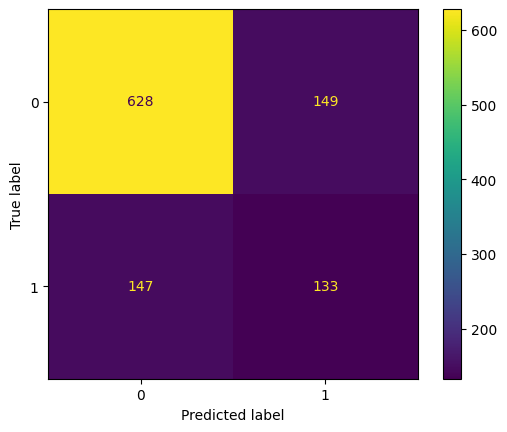

In [36]:
print('Árbol de Decisión')
print(classification_report(y_test, y_test_pred_arbol))
ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred_arbol);

Árbol de Decisión con max_depth
              precision    recall  f1-score   support

           0       0.85      0.89      0.86       777
           1       0.63      0.55      0.59       280

    accuracy                           0.80      1057
   macro avg       0.74      0.72      0.73      1057
weighted avg       0.79      0.80      0.79      1057



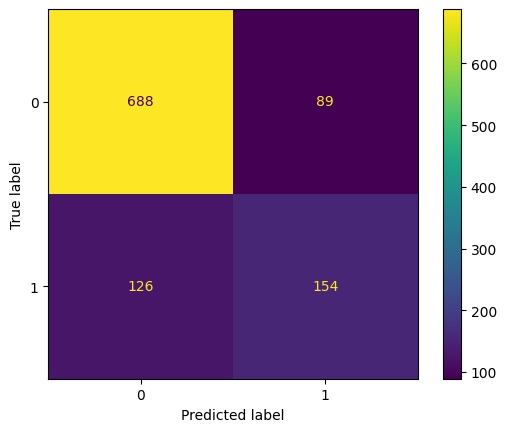

In [37]:
print('Árbol de Decisión con max_depth')
print(classification_report(y_test, y_test_pred_arbol_md))
ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred_arbol_md);

KNN
              precision    recall  f1-score   support

           0       0.83      0.86      0.85       777
           1       0.58      0.53      0.55       280

    accuracy                           0.77      1057
   macro avg       0.71      0.69      0.70      1057
weighted avg       0.77      0.77      0.77      1057



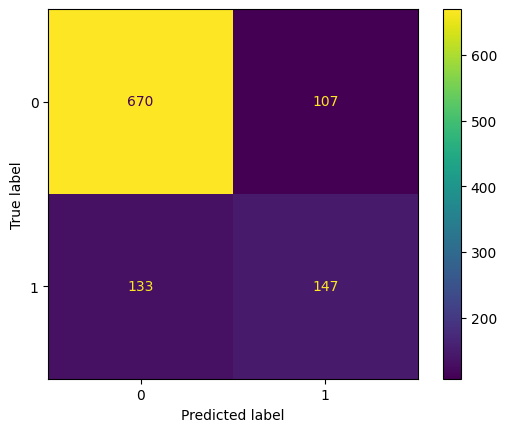

In [38]:
print('KNN')
print(classification_report(y_test, y_test_pred_knn))
ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred_knn);

KNN con normalización
              precision    recall  f1-score   support

           0       0.83      0.87      0.85       777
           1       0.59      0.52      0.55       280

    accuracy                           0.78      1057
   macro avg       0.71      0.70      0.70      1057
weighted avg       0.77      0.78      0.77      1057



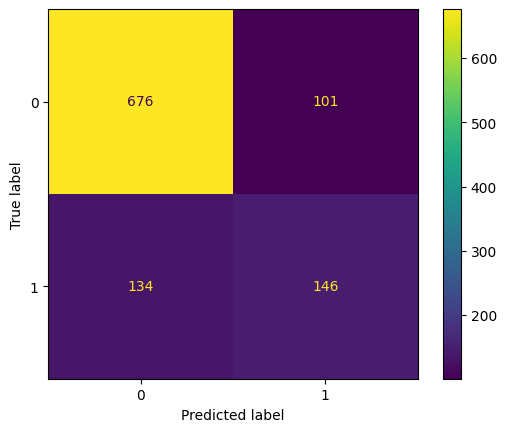

In [39]:
print('KNN con normalización')
print(classification_report(y_test, y_test_pred_knn_norm))
ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred_knn_norm);

Se utilizaron dos tipos de modelos, Árbol de Decisión y K-vecinos más cercanos. A su vez, el primero tiene dos versiones: uno sin y el otro con el parámetro max_depth. El segundo, si los datos fueron normalizados o no.

Todos estos modelos no estan balanceados.

Observemos las métricas recall, precision y f1-score.


| Modelo              | Recall | Precision | F1-score |
|---------------------|--------|-----------|----------|
| Árbol               | 0.47   | 0.47      | 0.47     |
| Árbol c/max_depth   | 0.63   | 0.55      | 0.59     |
| KNN                 | 0.58   | 0.53      | 0.55     |
| KNN c/normalización | 0.59   | 0.52      | 0.55     |

* Recall nos da la probabilidad de que el modelo detecte efectivamente a un cliente como "fugado", es decir, de cada 100 personas realmente fugadas, cuántas es capaz de detectar. Por ejemplo, en el primer modelo, podríamos decir que de cada 100 personas fugadas, detecta solamente 47 de estas.

* Precision nos indica la probabilidad de que aquel cliente que el modelo catalogó como "fugado", realmente sea así. En otras palabras, de cada 100 personas que el modelo clasificó como "fugado", cuántas de estas efectivamente lo fueron. Por ejemplo, en el primer modelo, podríamos decir que de cada 100 personas catalogadas como fugadas, 47 clientes en realidad lo son.

* F1-score combina los valores de Recall y Precision.

En este análisis en particular, se priorizará F1-score ya que nos interesa minimizar tanto la cantidad de Falsos Positivos (clientes activos que son calificados como fugados en nuestro modelo) y Falsos Negativos (clientes que se marcharon de la empresa pero el modelo lo clasificó como que aún permanecían).

Así, podemos decir que en orden de mayor a menor:

1. Con el modelo árbol con max_depth.
2. Con el modelo KNN con datos normalizados.
3. Con el modelo KNN sin datos normalizados.
4. Con el modelo árbol sin max_depth.

Ahora, se evaluará si algún modelo presentó overfitting o underfitting.

In [40]:
from sklearn.metrics import f1_score

f1_arbol = f1_score(y_test, y_test_pred_arbol)
f1_arbol_md = f1_score(y_test, y_test_pred_arbol_md)
f1_knn = f1_score(y_test, y_test_pred_knn)
f1_knn_norm = f1_score(y_test, y_test_pred_knn_norm)

# crear dataframe
f1scores = pd.DataFrame({
    'Modelo' : ['Árbol de Decisión (sin max_depth)',
                'Árbol de Decisión (con max_depth)',
                'K-vecinos más cercanos (sin normalización)',
                'K-vecinos más cercanos (con normalización)'],
    'F1-scores' : [f1_arbol,
                  f1_arbol_md,
                  f1_knn,
                  f1_knn_norm]
})

# imprimir
print(f1scores.sort_values(by='F1-scores',ascending=False))

                                       Modelo  F1-scores
1           Árbol de Decisión (con max_depth)   0.588910
3  K-vecinos más cercanos (con normalización)   0.554080
2  K-vecinos más cercanos (sin normalización)   0.550562
0           Árbol de Decisión (sin max_depth)   0.473310


In [41]:
f1_arbol_train = f1_score(y_train, y_train_pred_arbol)
f1_arbol_md_train = f1_score(y_train, y_train_pred_arbol_md)
f1_knn_train = f1_score(y_train, y_train_pred_knn)
f1_knn_norm_train = f1_score(y_train, y_train_pred_knn_norm)

dif_arbol = (f1_arbol_train - f1_arbol)
dif_arbol_md = (f1_arbol_md_train - f1_arbol_md)
dif_knn = (f1_knn_train - f1_knn)
dif_knn_norm = (f1_knn_norm_train - f1_knn_norm)

# crear dataframe
fitting = pd.DataFrame({
    'Modelo' : ['Árbol de Decisión',
                'Árbol de Decisión con max_depth',
                'KNN',
                'KNN con normalización'],
    'Train' : [f1_arbol_train,
                        f1_arbol_md_train,
                        f1_knn_train,
                        f1_knn_norm_train],
     'Test' : [f1_arbol,
                        f1_arbol_md,
                        f1_knn,
                        f1_knn_norm],
    'Diferencia' : [dif_arbol,
                        dif_arbol_md,
                        dif_knn,
                        dif_knn_norm]
})

# imprimir
print(f'''F1 Score de Train y Test
{fitting}''')

F1 Score de Train y Test
                            Modelo     Train      Test  Diferencia
0                Árbol de Decisión  0.994632  0.473310    0.521323
1  Árbol de Decisión con max_depth  0.611631  0.588910    0.022721
2                              KNN  0.672076  0.550562    0.121514
3            KNN con normalización  0.660612  0.554080    0.106532


1. El modelo árbol sin max_depth, presenta overfitting debido a la gran diferencia entre los valores Train y Test. El modelo memorizó los datos de entrenamiento y a la hora de introducir nuevos datos (Test), solo identifica el 47%.
2. El modelo árbol con max_depth, presenta buena capacidad de generalizacion.
3. El modelo KNN sin normalización, presenta leve overfitting. Hay una diferencia de 12 puntos.  
4. El modelo KNN con normalización, presenta leve overfitting. Es el segundo modelo que presenta mejor generalización, después del modelo árbol con max_depth.

Entonces tenemos por el momento los dos mejores modelos: Árbol de Decisión con max_depth y KNN con normalización. A continuación se ajustaran los modelos para obtener el mejor.



### Árbol de Decisión con max_depth

Este modelo es muy simple. Aunque ya se realizó un GridSearchCV para buscar max_depth anteriormente, en esta intancia buscaremos otros hiperparámetros importantes.

In [42]:
# separar subconjuntos k
cv = KFold(n_splits=5, shuffle=True, random_state=5)

# establecer rangos hiperparámetros
param_grid = {
    'max_depth': list(range(1,12)),
    'min_samples_split': list(range(2,20)),
    'min_samples_leaf': list(range(1,10))
}

# aplicar gridsearcgcv
grid = GridSearchCV(
    modelo_arbol,
    param_grid,
    cv=cv,
    scoring='f1'
)

# entrenar
grid.fit(X_train, y_train)

# imprimir
print(grid.best_params_)
print(grid.best_estimator_)

{'max_depth': 6, 'min_samples_leaf': 1, 'min_samples_split': 4}
DecisionTreeClassifier(max_depth=6, min_samples_split=4, random_state=5)


Es este nuevo modelo, modelo nro 2, se agregará unicamente min_samples_split.

In [43]:
# nuevo modelo arbol con min_samples_split agregado

# instanciar nuestro modelo
modelo_arbol = DecisionTreeClassifier(max_depth=6,
                                      min_samples_split=4,
                                      random_state=5)

# entrenar nuestros datos
modelo_arbol.fit(X_train,y_train)

# utilizar el método predict
y_test_pred_arbol_n = modelo_arbol.predict(X_test)
y_train_pred_arbol_n = modelo_arbol.predict(X_train)

# F1 score
n_f1_arbol = f1_score(y_test, y_test_pred_arbol_n)
n_f1_arbol_train = f1_score(y_train, y_train_pred_arbol_n)
n_dif_arbol = (n_f1_arbol_train - n_f1_arbol)

Los datos se encuentran desbalanceados, por ende, se introduce en la versión nro 3 de este modelo, class_weight, para observar si hay mejores resultados.

In [44]:
# nuevo modelo arbol con class_weight agregado

# instanciar nuestro modelo
modelo_arbol = DecisionTreeClassifier(max_depth=6,
                                      min_samples_split=4,
                                      random_state=5,
                                      class_weight='balanced')

# entrenar nuestros datos
modelo_arbol.fit(X_train,y_train)

# utilizar el método predict
y_test_pred_arbol_n2 = modelo_arbol.predict(X_test)
y_train_pred_arbol_n2 = modelo_arbol.predict(X_train)

# F1 score
n2_f1_arbol = f1_score(y_test, y_test_pred_arbol_n2)
n2_f1_arbol_train = f1_score(y_train, y_train_pred_arbol_n2)
n2_dif_arbol = (n2_f1_arbol_train - n2_f1_arbol)

In [45]:
modeloarbolfinal = pd.DataFrame({
    'Modelo' : ['C/max_depth',
                '+ min_samples_split',
                '+ class_weight'],
    'Train' : [f1_arbol_md_train,
               n_f1_arbol_train,
              n2_f1_arbol_train],
     'Test' : [f1_arbol,
               n_f1_arbol,
               n2_f1_arbol],
    'Diferencia' : [dif_arbol_md,
                    n_dif_arbol,
                    n2_dif_arbol]
})

print(modeloarbolfinal)

                Modelo     Train      Test  Diferencia
0          C/max_depth  0.611631  0.473310    0.022721
1  + min_samples_split  0.611631  0.588910    0.022721
2       + class_weight  0.640523  0.611187    0.029336


Como se puede observar, la versión nro 3 es el modelo de árbol de decisión mejor planteado. La diferencia entre Train y Test es pequeña, por ende, no presenta overfitting ni underfitting y el F1-score llega por encima del 60%.

### KNN con normalización

Posee un leve overfitting. En la versión anterior, únicamente se modificó la normalización de los datos. A continuación, se buscará mejorar otros parámetros.

In [46]:
cv = KFold(n_splits=5, shuffle=True, random_state=5)

# preparar parametros
param_grid = {
    'n_neighbors': range(1, 20),
    'weights': ['uniform', 'distance'], # cómo se vota, por defecto es uniform
    'metric': ['euclidean', 'manhattan'] # fórmula para medir la cercanía, por defecto es euclidean
}

# aplicar gridsearchcv
grid = GridSearchCV(
    modelo_knn,
    param_grid,
    cv=cv,
    scoring='f1'
)

# entrenar
grid.fit(X_train_normalizado, y_train)

# imprimir
print("Mejores parámetros:", grid.best_params_)
print("F1-score más alto:", grid.best_score_)

Mejores parámetros: {'metric': 'euclidean', 'n_neighbors': 17, 'weights': 'uniform'}
F1-score más alto: 0.5451166148569103


In [47]:
# nuevo modelo con los datos normalizados

# instanciar nuestro modelo
modelo_knn = KNeighborsClassifier(n_neighbors=17)

# entrenar nuestros datos
modelo_knn.fit(X_train_normalizado,y_train)

# normalizar X_test
X_test_normalizado = normalizacion.fit_transform(X_test)

# utilizar el método predict
y_test_pred_knn_norm_n = modelo_knn.predict(X_test_normalizado)
y_train_pred_knn_norm_n = modelo_knn.predict(X_train_normalizado)

# F1 score
n_f1_knn = f1_score(y_test, y_test_pred_knn_norm_n)
n_f1_knn_train = f1_score(y_train, y_train_pred_knn_norm_n)
n_dif_knn = (n_f1_knn_train - n_f1_knn)

In [48]:
modeloknnfinal = pd.DataFrame({
    'Modelo' : ['KNN',
                '+ n_neighbours, weights y metric'],
    'Train' : [f1_knn_norm_train,
              n_f1_knn_train],
     'Test' : [f1_knn_norm,
               n_f1_knn],
    'Diferencia' : [dif_knn_norm,
                    n_dif_knn]
})

print(modeloknnfinal)

                             Modelo     Train      Test  Diferencia
0                               KNN  0.660612  0.554080    0.106532
1  + n_neighbours, weights y metric  0.601060  0.597303    0.003758


Esta nueva versión de K-vecinos más próximos presenta una diferencia mínima entre el F1-score de Train y Test, por lo que tenemos un modelo que dejó de memorizar y generaliza mejor que la versión más antigua.

# 📋 Interpretación y Conclusiones

## Análisis de la Importancia de las Variables

### Árbol de Decisión

In [49]:
# aplicar feature_importances_ para obtener puntaje de cada variable
variables_arbol = modelo_arbol.feature_importances_

# crear dataframe que contengan las variables
variables_arbol_df = pd.DataFrame({
    'Variable': X.columns,
    'Puntaje': variables_arbol
})

variables_arbol_df = variables_arbol_df.sort_values(by='Puntaje', ascending=False)
variables_arbol_df = variables_arbol_df.reset_index(drop=True)

# imprimir
print(variables_arbol_df)

                                   Variable   Puntaje
0                   Contract Month-to-month  0.570989
1                            ChargesMonthly  0.185403
2                                    Tenure  0.124403
3            PaymentMethod Electronic check  0.021350
4                           InternetService  0.017641
5                         Contract One year  0.015800
6                            StramingMovies  0.012512
7                         Contract Two year  0.009799
8                               TechSupport  0.008856
9                                Dependents  0.008438
10                            MultipleLines  0.007754
11                           OnlineSecurity  0.006369
12    PaymentMethod Credit card (automatic)  0.003969
13                         PaperlessBilling  0.003604
14                            SeniorCitizen  0.003114
15                                  Partner  0.000000
16                             OnlineBackup  0.000000
17                          

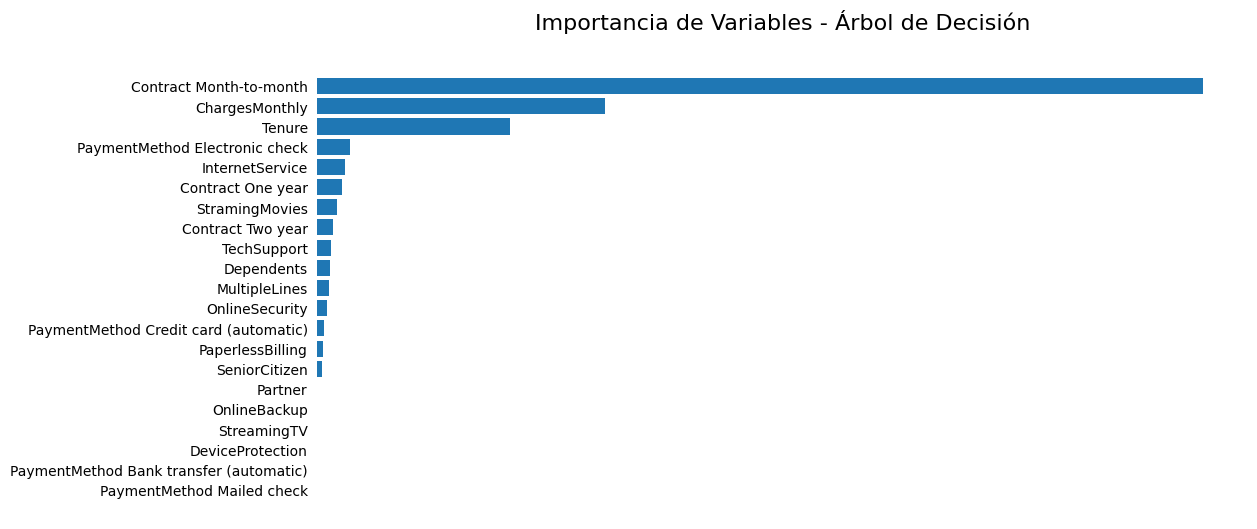

In [50]:
# graficar
fig, ax = plt.subplots(figsize=(12,6))

ax.barh(variables_arbol_df['Variable'],
        variables_arbol_df['Puntaje'])

ax.set_title('Importancia de Variables - Árbol de Decisión', loc='center', fontsize=16, pad=20)
ax.set_xlabel('')
ax.set_ylabel('')
ax.set_xticks([])
ax.tick_params(left=False)
ax.invert_yaxis()

for spine in ax.spines.values():
    spine.set_visible(False)

plt.show()

En el modelo árbol de decisión, se utilizó el atributo feature_importances_ para medir cuánto contribuyó cada variable a que el modelo tome decisiones correctas. Como se puede observar, "Contract Month-to-month", "ChargesMonthly" y "Tenure" son las más utilizadas, mientras que "Partner", "OnlineBackup", "StreamingTV", "DeviceProtection", "PaymentMethod Bank transfer (automatic)" y "PaymentMethod Mailed check" no fueron utilizadas en absoluto.

### K-vecinos más cercanos (KNN)

In [51]:
# importar
from sklearn.inspection import permutation_importance

# aplicar permution_importance
variables_knn = permutation_importance(modelo_knn,
                                       X_test_normalizado,
                                       y_test,
                                       scoring='f1',
                                       n_repeats=10,
                                       random_state=5)

# crear dataframe que contengan las variables
variables_knn_df = pd.DataFrame({
    'Variable': X.columns,
    'Puntaje': variables_knn.importances_mean
})

variables_knn_df = variables_knn_df.sort_values(by='Puntaje', ascending=False)
variables_knn_df = variables_knn_df.reset_index(drop=True)

# imprimir
print(variables_knn_df)

                                   Variable   Puntaje
0                                    Tenure  0.100073
1            PaymentMethod Electronic check  0.028870
2                               TechSupport  0.028240
3                            OnlineSecurity  0.027109
4                           InternetService  0.026775
5                            ChargesMonthly  0.025329
6                          PaperlessBilling  0.024309
7                             MultipleLines  0.020651
8                              OnlineBackup  0.020336
9                   Contract Month-to-month  0.014235
10               PaymentMethod Mailed check  0.013062
11                         DeviceProtection  0.012882
12                               Dependents  0.010797
13    PaymentMethod Credit card (automatic)  0.007226
14                                  Partner  0.006546
15                           StramingMovies  0.004449
16  PaymentMethod Bank transfer (automatic)  0.004002
17                          

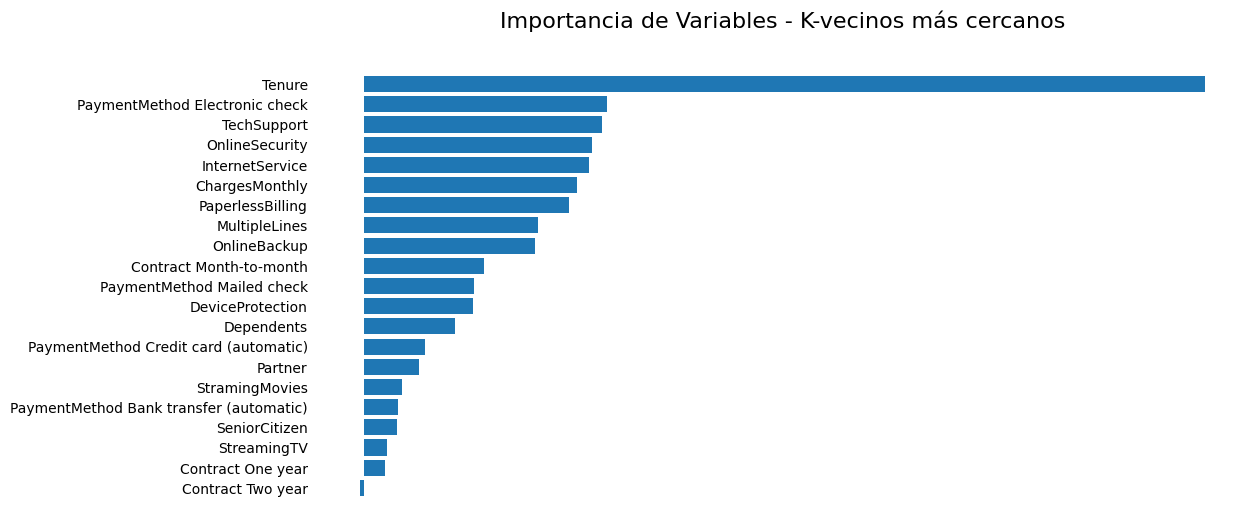

In [52]:
# graficar
fig, ax = plt.subplots(figsize=(12,6))

ax.barh(variables_knn_df['Variable'],
        variables_knn_df['Puntaje'])

ax.set_title('Importancia de Variables - K-vecinos más cercanos', loc='center', fontsize=16, pad=20)
ax.set_xlabel('')
ax.set_ylabel('')
ax.set_xticks([])
ax.tick_params(left=False)
ax.invert_yaxis()

for spine in ax.spines.values():
    spine.set_visible(False)

plt.show()

En el modelo K-vecinos más cercanos, se utilizó permutation_importance de SKLearn para medir cuánto contribuyó cada variable a que el modelo tome decisiones correctas. Como se puede observar, "Tenure", "PaymentMethod Electronic check" y "TechSupport" son las más utilizadas.

## Conclusión

Se construyeron dos modelos, Árbol de Decisión y K-vecinos más cercanos (KNN), se entrenaron, se evaluaron y se optimizaron posteriormente para poder lograr el mejor rendimiento para ambos.

El primero obtuvo un F1-score de 0.640523 en el conjunto de entrenamiento y 0.611187 en el de prueba, mientras que el segundo logró 0.601060 y 0.597303 respectivamente. Y si bien el modelo KNN presentó la diferencia menor (0.003758 vs 0.029336), es el modelo Árbol de Decisión optimizado sus hiperparámetros que logró posicionarse como el mejor desempeño predictivo por lograr un puntaje de 0.61 con los nuevos datos.

Las variables más importantes o, mejor dicho, más peso tienen dependen de cada modelo. Hay incluso algunas, que no fueron utilizadas al ejecutarse o solo agregan "suciedad" al modelo. A continuación, se muestran las 10 primeras:

| Modelo | Árbol de Decisión              | KNN                            |
|--------|--------------------------------|--------------------------------|
| 1      | Contract Month-to-moth         | Tenure                         |
| 2      | ChargesMonthly                 | PaymentMethod Electronic check |
| 3      | Tenure                         | TechSupport                    |
| 4      | PaymentMethod Electronic check | OnlineSecurity                 |
| 5      | InternerService                | InternetService                |
| 6      | Contract One year              | ChargesMonthly                 |
| 7      | StramingMovies                 | PaperlessBilling               |
| 8      | Contract Two year              | MultipleLines                  |
| 9      | TechSupport                    | OnlineBackup                   |
| 10     | Dependents                     | Contract Month-to-month        |

Los variables que se repitieron en ambos casos dentro de los 10 primeros son los siguientes:

1. Contract Month-to-Month
2. ChargesMonthly
3. Tenure
4. PaymentMethod Electronic check
5. InternetService
6. TechSupport



A diferencia del Challenge anterior, donde las características del perfil del cliente (edad, si tenía pareja o adicionales) tenían peso en la decisión de irse o no, en esta ocasión las variables se enfocan en las preferencias del cliente con respecto al servicio.

La mayor concentración de bajas se registran durante el primer año de servicio (Tenure), por ende, es natural que el cliente opte por el tipo de contrato mes a mes (Contract Month-to-month). Se sugiere la existencia de una posible sensibilidad al precio o una percepción insuficiente de valor en relación con el costo (ChargesMonthly).

Esa percepción puede ser que esté relacionada a las otras variables: PaymentMethod Electronic check, Internet y Tech Support. Podría existir un descontento generalizado del cliente por cómo funcionan o no y la capacidad de respuesta que tiene la empresa a solucionar ese malestar.


### Recomendaciones

* Realizar encuestas de satisfacción para detectar fricciones antes que el cliente decida cancelar durante el primer año de servicio.
* Ofrecer beneficios adicionales o acumulativos por permanencia, como descuento escalonado automático, servicios extras, mayor velocidad de internet, soporte prioritario.
* Diseñar planes más flexibles o personalizados según las preferencias del cliente.
* Fortalecer los canales de soporte técnico y analizar reclamos frecuentes para identificar fallas estructurales.
* Ofrecer bonificación por adherirse a medios de pagos automáticos.
* Revisar el proceso de pago del cheque electrónico con respecto a otros medios, ante la posibilidad de insatisfacción del cliente con el servicio.